# Train Flood Severity Classification — MobileNetV3 Large Complete Fixed

Notebook này được viết lại từ cấu trúc train hiện tại, nhưng **chỉ tập trung vào MobileNetV3 Large**.

## Mục tiêu chỉnh sửa

- Giữ cấu trúc train hiện tại: mount Drive → config → extract dataset → clean/split → dataloader → build model → train → evaluate → confusion matrix → misclassified → inference.
- Cố định model là **MobileNetV3 Large pretrained ImageNet**.
- Bổ sung các phần còn thiếu sau khi relabel:
  - Kiểm tra duplicate/cross-label duplicate.
  - Lưu `train/val/test split` để tránh lệch evaluation.
  - Early stopping theo `val_macro_f1`.
  - Class weight nhẹ, tránh ép `high` quá mạnh làm `medium → high`.
  - Differential learning rate: backbone LR nhỏ, classifier head LR lớn hơn.
  - Lưu checkpoint đầy đủ metadata: `class_order`, transform, config, split.
  - Xuất `classification_report`, confusion matrix raw/normalized.
  - Xuất ảnh đoán sai theo từng cặp lỗi để tiếp tục relabel.
  - Fix cảnh báo AMP mới: dùng `torch.amp.autocast` và `torch.amp.GradScaler`.

## Class cố định

- `low`
- `medium`
- `high`
- `non_flood`

## Guideline relabel

| Class | Tiêu chí |
|---|---|
| `non_flood` | Không có nước ngập rõ ràng; đường khô/ướt/mưa/vũng nước nhỏ nhưng chưa phải ngập. |
| `low` | Có nước ngập rõ, nhưng dưới gối người; dưới thân thấp xe máy; dưới phần chính của bánh xe ô tô. |
| `medium` | Nước khoảng từ gối đến dưới ngực; tới/yên xe máy hoặc gần yên; qua bánh xe ô tô. |
| `high` | Nước từ ngực trở lên; qua tay lái xe máy; tới cửa kính/mái xe; ngập sâu vào nhà/cửa sổ. |

## Bản cập nhật trong file này

- Đặt `NUM_WORKERS = 0` mặc định để tránh lỗi `_MultiProcessingDataLoaderIter.__del__` trên Colab/notebook.
- Thêm hàm `make_loader()` để cấu hình `persistent_workers` và `prefetch_factor` chỉ khi `NUM_WORKERS > 0`.
- Dùng `pin_memory` chỉ khi có CUDA.
- Dùng `torch.amp.autocast(device_type=device.type, ...)` để tương thích hơn.
- Giữ checkpoint tốt nhất theo `val_macro_f1`, lưu `last checkpoint`, history, confusion matrix và danh sách ảnh đoán sai.

## Update solution 17/06

File này đã được chỉnh theo hướng giảm overfitting và giữ lại mốc tham chiếu độ sâu nước:

- `HEAD_LR = 2e-4` thay vì `3e-4`.
- `DROPOUT = 0.35` giữ nguyên.
- Perceptual audit bằng dHash; ảnh gần giống được buộc ở cùng group, group xung đột nhãn bị loại để review.
- Split train/val/test theo perceptual group để ngăn data leakage.
- Train/val/test/inference dùng chung letterbox 224×224, không crop và không kéo giãn ảnh.
- Mọi artifact mới ghi vào `mobilenetv3_large_relabel_v2`; báo cáo cuối chỉ dùng test split độc lập.



In [1]:
# Nếu chạy trên Google Colab, cell này sẽ mount Google Drive.
# try:
#     from google.colab import drive
#     drive.mount('/content/drive')
# except Exception as e:
#     print('Không chạy trong Colab hoặc không cần mount Drive:', repr(e))

## 1. Import thư viện

In [2]:
import os
import json
import random
import shutil
import zipfile
import hashlib
from pathlib import Path
from collections import Counter, defaultdict
from datetime import datetime

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from PIL import Image, ImageFile, ImageOps
ImageFile.LOAD_TRUNCATED_IMAGES = True

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
from torchvision import transforms, models

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    f1_score,
    precision_recall_fscore_support,
    classification_report,
    confusion_matrix,
)

try:
    from tqdm.auto import tqdm
except Exception:
    tqdm = lambda x, **kwargs: x

## 2. Cấu hình

In [3]:
# =========================
# CONFIG — MOBILENETV3 LARGE ONLY
# =========================
SEED = 42

# Mapping cố định. Không đổi thứ tự này nếu app inference đang dùng checkpoint theo thứ tự này.
CLASS_ORDER = ["low", "medium", "high", "non_flood"]
CLASS_TO_IDX = {name: idx for idx, name in enumerate(CLASS_ORDER)}
IDX_TO_CLASS = {idx: name for name, idx in CLASS_TO_IDX.items()}

# Các folder review/không chắc chắn sẽ bị bỏ qua nếu có trong dataset.
IGNORE_DIR_NAMES = {
    "uncertain", "need_review", "review", "unknown", "ambiguous",
    "ignore", "ignored", "trash", "_trash", "duplicates", "conflict",
    "misclassified", "wrong", "_review",
}

# Dataset folder hoặc zip. Folder local được ưu tiên; zip vẫn dùng được trên Colab.
# Dùng đường dẫn tương đối để chạy được trên máy khác.
DATASET_DIR_CANDIDATES = [
    str(Path.cwd() / "model" / "Dataset_Flood"),
    str(Path.cwd() / "Dataset_Flood"),
]

# Dataset zip sau khi relabel; dùng khi không tìm thấy folder local.
ZIP_PATH_CANDIDATES = [
    "/content/drive/MyDrive/Colab Notebooks/NCKH/Dataset_relabel.zip",
    "/content/drive/MyDrive/Colab Notebooks/NCKH/Dataset_relabeled.zip",
    # "/content/drive/MyDrive/Colab Notebooks/NCKH/Dataset_clean.zip",
    # "/content/drive/MyDrive/Colab Notebooks/NCKH/Dataset.zip",
    # "/content/Dataset_relabel.zip",
    # "/content/Dataset_relabeled.zip",
    # "/content/Dataset_clean.zip",
    # "/content/Dataset.zip",
    # "/mnt/data/Dataset_relabel.zip",
    # "/mnt/data/Dataset_relabeled.zip",
    # "/mnt/data/Dataset_clean.zip",
    # "/mnt/data/Dataset.zip",
]

EXTRACT_DIR = "/content/flood_dataset_relabel" if os.path.exists("/content") else "./flood_dataset_relabel"

# Tách output riêng cho MobileNetV3 Large để không lẫn checkpoint/model khác.
BASE_OUTPUT_DIR = "/content/drive/MyDrive/Colab Notebooks/NCKH/models" if os.path.exists("/content/drive") else "./models"
MODEL_VERSION = "v2"
OUTPUT_DIR = os.path.join(BASE_OUTPUT_DIR, "mobilenetv3_large_relabel_v2")
os.makedirs(OUTPUT_DIR, exist_ok=True)

# Model — cố định MobileNetV3 Large.
MODEL_NAME = "mobilenetv3_large"
PRETRAINED = True
IMAGE_SIZE = 224
LETTERBOX_FILL = (124, 116, 104)
DROPOUT = 0.35

# Training.
BATCH_SIZE = 32
NUM_EPOCHS = 35
BACKBONE_LR = 1e-5      # LR thấp để không phá feature pretrained.
HEAD_LR = 2e-4          # Giảm từ 3e-4 để hạn chế overfit/confidence sai ở classifier head.
WEIGHT_DECAY = 5e-4     # tăng nhẹ để giảm overfit.
LABEL_SMOOTHING = 0.05
PATIENCE = 7
NUM_WORKERS = 0  # Colab-safe. Nếu muốn tăng tốc, thử 2 sau khi train ổn định.
USE_AMP = True

# Split.
VAL_SIZE = 0.15
TEST_SIZE = 0.15

# Duplicate handling.
DEDUP_EXACT = True
PERCEPTUAL_HASH_DISTANCE = 3
PERCEPTUAL_MEAN_L1 = 30
EXCLUDE_CONFLICT_DUPLICATES = True

# Imbalance handling.
# Không bật đồng thời sampler và class_weight nếu không thật sự hiểu tác động.
USE_WEIGHTED_SAMPLER = False
USE_CLASS_WEIGHT_LOSS = True

# Class weight nhẹ theo sqrt inverse frequency.
# Mục tiêu: hỗ trợ class ít như high nhưng không ép quá mạnh gây medium -> high.
CLASS_WEIGHT_POWER = 0.5
MIN_CLASS_WEIGHT = 0.70
MAX_CLASS_WEIGHT = 2.00
EXTRA_CLASS_MULTIPLIER = {
    "low": 1.00,
    "medium": 1.00,
    "high": 1.15,
    "non_flood": 1.00,
}

# Metric chọn checkpoint tốt nhất.
# Với dataset lệch class, macro_f1 hoặc balanced_acc tốt hơn accuracy.
BEST_METRIC = "macro_f1"  # "macro_f1" hoặc "balanced_acc"

SAVE_NAME = f"flood_{MODEL_NAME}_relabel_{MODEL_VERSION}_best.pth"
BEST_CKPT_PATH = os.path.join(OUTPUT_DIR, SAVE_NAME)
LAST_CKPT_PATH = os.path.join(OUTPUT_DIR, f"flood_{MODEL_NAME}_relabel_{MODEL_VERSION}_last.pth")

SPLIT_CSV_PATH = os.path.join(OUTPUT_DIR, "split_train_val_test_mobilenetv3_large_v2.csv")
HISTORY_CSV_PATH = os.path.join(OUTPUT_DIR, "history_mobilenetv3_large_v2.csv")
CONFIG_JSON_PATH = os.path.join(OUTPUT_DIR, "config_mobilenetv3_large_v2.json")

CONFIG = {
    "model_version": MODEL_VERSION,
    "seed": SEED,
    "class_order": CLASS_ORDER,
    "model_name": MODEL_NAME,
    "pretrained": PRETRAINED,
    "image_size": IMAGE_SIZE,
    "preprocess": "letterbox",
    "letterbox_fill": LETTERBOX_FILL,
    "dropout": DROPOUT,
    "batch_size": BATCH_SIZE,
    "num_epochs": NUM_EPOCHS,
    "backbone_lr": BACKBONE_LR,
    "head_lr": HEAD_LR,
    "weight_decay": WEIGHT_DECAY,
    "label_smoothing": LABEL_SMOOTHING,
    "patience": PATIENCE,
    "num_workers": NUM_WORKERS,
    "use_amp": USE_AMP,
    "val_size": VAL_SIZE,
    "test_size": TEST_SIZE,
    "perceptual_hash_distance": PERCEPTUAL_HASH_DISTANCE,
    "perceptual_mean_l1": PERCEPTUAL_MEAN_L1,
    "use_weighted_sampler": USE_WEIGHTED_SAMPLER,
    "use_class_weight_loss": USE_CLASS_WEIGHT_LOSS,
    "class_weight_power": CLASS_WEIGHT_POWER,
    "extra_class_multiplier": EXTRA_CLASS_MULTIPLIER,
    "best_metric": BEST_METRIC,
}

with open(CONFIG_JSON_PATH, "w", encoding="utf-8") as f:
    json.dump(CONFIG, f, ensure_ascii=False, indent=2)

print("CLASS_TO_IDX:", CLASS_TO_IDX)
print("OUTPUT_DIR:", OUTPUT_DIR)
print("BEST_CKPT_PATH:", BEST_CKPT_PATH)
print("CONFIG_JSON_PATH:", CONFIG_JSON_PATH)

CLASS_TO_IDX: {'low': 0, 'medium': 1, 'high': 2, 'non_flood': 3}
OUTPUT_DIR: ./models\mobilenetv3_large_relabel
BEST_CKPT_PATH: ./models\mobilenetv3_large_relabel\flood_mobilenetv3_large_relabel_best.pth
CONFIG_JSON_PATH: ./models\mobilenetv3_large_relabel\config_mobilenetv3_large.json


In [4]:
import logging
import sys

LOG_PATH = os.path.join(OUTPUT_DIR, "training.log")

logger = logging.getLogger("flood_training")
logger.setLevel(logging.INFO)
logger.propagate = False

if not logger.handlers:
    formatter = logging.Formatter(
        "%(asctime)s | %(levelname)s | %(message)s",
        datefmt="%Y-%m-%d %H:%M:%S",
    )

    console_handler = logging.StreamHandler(sys.stdout)
    console_handler.setFormatter(formatter)
    logger.addHandler(console_handler)

    file_handler = logging.FileHandler(LOG_PATH, encoding="utf-8")
    file_handler.setFormatter(formatter)
    logger.addHandler(file_handler)

logger.info("Logger initialized")
logger.info("Output directory: %s", OUTPUT_DIR)
logger.info("Log file: %s", LOG_PATH)

2026-09-07 11:48:27 | INFO | Logger initialized
2026-09-07 11:48:27 | INFO | Output directory: ./models\mobilenetv3_large_relabel
2026-09-07 11:48:27 | INFO | Log file: ./models\mobilenetv3_large_relabel\training.log


In [5]:
def seed_everything(seed: int = 42):
    random.seed(seed)
    os.environ["PYTHONHASHSEED"] = str(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

    # benchmark=True nhanh hơn cho image size cố định.
    # deterministic=False chấp nhận sai khác rất nhỏ giữa các lần chạy để tăng tốc.
    torch.backends.cudnn.deterministic = False
    torch.backends.cudnn.benchmark = True

seed_everything(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

if USE_WEIGHTED_SAMPLER and USE_CLASS_WEIGHT_LOSS:
    raise ValueError("Không nên bật đồng thời USE_WEIGHTED_SAMPLER và USE_CLASS_WEIGHT_LOSS.")

if BEST_METRIC not in {"macro_f1", "balanced_acc"}:
    raise ValueError("BEST_METRIC chỉ nên là 'macro_f1' hoặc 'balanced_acc'.")

Device: cuda


## 3. Nạp dataset folder hoặc giải nén zip

In [6]:
def find_existing_zip(candidates):
    return next((p for p in candidates if Path(p).is_file()), None)

def find_existing_dataset_dir(candidates, expected_classes):
    expected = set(expected_classes)
    for candidate in candidates:
        path = Path(candidate)
        if path.is_dir() and expected.issubset({p.name for p in path.iterdir() if p.is_dir()}):
            return str(path)
    return None

dataset_dir = find_existing_dataset_dir(DATASET_DIR_CANDIDATES, CLASS_ORDER)
if dataset_dir is not None:
    EXTRACT_DIR = dataset_dir
    print("Using dataset folder:", EXTRACT_DIR)
else:
    zip_path = find_existing_zip(ZIP_PATH_CANDIDATES)
    if zip_path is None:
        raise FileNotFoundError(
            "Không tìm thấy folder Dataset_Flood hoặc dataset zip."
        )

    print("Using zip:", zip_path)
    if os.path.exists(EXTRACT_DIR):
        shutil.rmtree(EXTRACT_DIR)
    os.makedirs(EXTRACT_DIR, exist_ok=True)

    with zipfile.ZipFile(zip_path, "r") as zf:
        zf.extractall(EXTRACT_DIR)

    print("Extracted to:", EXTRACT_DIR)

Using dataset folder: e:\RHNA\1Visual\NCKH\model\Dataset_Flood


In [7]:
def find_dataset_root(base_dir, expected_classes):
    expected = set(expected_classes)
    for root, dirs, files in os.walk(base_dir):
        dir_set = set(dirs)
        if expected.issubset(dir_set):
            return root
    return None

DATA_DIR = find_dataset_root(EXTRACT_DIR, CLASS_ORDER)
if DATA_DIR is None:
    raise FileNotFoundError(
        f"Không tìm thấy folder chứa đủ các class {CLASS_ORDER} trong {EXTRACT_DIR}.\n"
        "Cấu trúc đúng nên là: Dataset/low, Dataset/medium, Dataset/high, Dataset/non_flood"
    )

print("DATA_DIR:", DATA_DIR)
print("Subfolders:", sorted([p.name for p in Path(DATA_DIR).iterdir() if p.is_dir()]))

# Cảnh báo nếu có folder không nằm trong CLASS_ORDER hoặc IGNORE_DIR_NAMES.
extra_dirs = []
for p in Path(DATA_DIR).iterdir():
    if p.is_dir() and p.name not in CLASS_ORDER and p.name not in IGNORE_DIR_NAMES:
        extra_dirs.append(p.name)
if extra_dirs:
    print("Warning — folder không thuộc class/ignore:", extra_dirs)

DATA_DIR: e:\RHNA\1Visual\NCKH\model\Dataset_Flood
Subfolders: ['high', 'low', 'medium', 'non_flood']


## 4. Kiểm tra dataset: class count, ảnh lỗi, duplicate

In [8]:
VALID_EXTS = {".jpg", ".jpeg", ".png", ".bmp", ".webp", ".avif"}

def md5_file(path, chunk_size=1024 * 1024):
    h = hashlib.md5()
    with open(path, "rb") as f:
        for chunk in iter(lambda: f.read(chunk_size), b""):
            h.update(chunk)
    return h.hexdigest()


def is_valid_image(path):
    try:
        with Image.open(path) as img:
            img.verify()
        return True, ""
    except Exception as e:
        return False, repr(e)


def collect_image_records(data_dir, class_order):
    rows = []
    invalid_rows = []

    data_dir = Path(data_dir)
    for label in class_order:
        class_dir = data_dir / label
        if not class_dir.exists():
            raise FileNotFoundError(f"Missing class folder: {class_dir}")

        for p in class_dir.rglob("*"):
            if p.is_dir():
                continue

            # Bỏ qua file trong folder review/ignore nếu người dùng vô tình đặt bên trong class.
            parts_lower = {part.lower() for part in p.parts}
            if any(name.lower() in parts_lower for name in IGNORE_DIR_NAMES):
                continue

            if p.suffix.lower() not in VALID_EXTS:
                continue

            ok, err = is_valid_image(str(p))
            if not ok:
                invalid_rows.append({
                    "path": str(p),
                    "label": label,
                    "error": err,
                })
                continue

            rows.append({
                "path": str(p),
                "label": label,
                "label_idx": CLASS_TO_IDX[label],
                "file_name": p.name,
                "md5": md5_file(str(p)),
            })

    records_df = pd.DataFrame(rows)
    invalid_df = pd.DataFrame(invalid_rows)
    return records_df, invalid_df


records_df, invalid_df = collect_image_records(DATA_DIR, CLASS_ORDER)

print("Valid image count:", len(records_df))
print("Invalid image count:", len(invalid_df))
print("\nClass counts before clean:")
print(records_df["label"].value_counts().reindex(CLASS_ORDER).fillna(0).astype(int))

records_path = os.path.join(OUTPUT_DIR, "records_before_clean_mobilenetv3_large.csv")
invalid_path = os.path.join(OUTPUT_DIR, "invalid_images_mobilenetv3_large.csv")
records_df.to_csv(records_path, index=False)
invalid_df.to_csv(invalid_path, index=False)

print("\nSaved:", records_path)
print("Saved:", invalid_path)

if len(invalid_df) > 0:
    display(invalid_df.head(20))

Valid image count: 1625
Invalid image count: 0

Class counts before clean:
label
low          388
medium       360
high         347
non_flood    530
Name: count, dtype: int64

Saved: ./models\mobilenetv3_large_relabel\records_before_clean_mobilenetv3_large.csv
Saved: ./models\mobilenetv3_large_relabel\invalid_images_mobilenetv3_large.csv


In [9]:
def build_clean_records(records_df):
    conflict_rows = []
    same_label_dup_rows = []
    keep_indices = []

    for md5, group in records_df.groupby("md5"):
        labels = sorted(group["label"].unique().tolist())

        if len(labels) > 1:
            # Một ảnh xuất hiện ở nhiều class khác nhau -> nguy hiểm, bỏ khỏi train.
            for _, row in group.iterrows():
                conflict_rows.append({
                    "md5": md5,
                    "path": row["path"],
                    "label": row["label"],
                    "conflict_labels": ",".join(labels),
                })
            if not EXCLUDE_CONFLICT_DUPLICATES:
                keep_indices.extend(group.index.tolist())
            continue

        # Trùng y hệt trong cùng class -> giữ 1 ảnh nếu DEDUP_EXACT=True.
        if len(group) > 1:
            sorted_group = group.sort_values("path")
            keep_idx = sorted_group.index[0]
            for dup_idx in sorted_group.index[1:]:
                same_label_dup_rows.append({
                    "md5": md5,
                    "kept_path": records_df.loc[keep_idx, "path"],
                    "duplicate_path": records_df.loc[dup_idx, "path"],
                    "label": records_df.loc[dup_idx, "label"],
                })
            if DEDUP_EXACT:
                keep_indices.append(keep_idx)
            else:
                keep_indices.extend(group.index.tolist())
        else:
            keep_indices.extend(group.index.tolist())

    clean_df = records_df.loc[sorted(set(keep_indices))].reset_index(drop=True).copy()
    conflict_df = pd.DataFrame(conflict_rows)
    same_label_dup_df = pd.DataFrame(same_label_dup_rows)
    return clean_df, conflict_df, same_label_dup_df


clean_df, conflict_df, same_label_dup_df = build_clean_records(records_df)


def perceptual_signature(path):
    """dHash 64-bit + mean RGB để audit ảnh gần giống mà không thêm dependency."""
    with Image.open(path) as img:
        rgb = img.convert("RGB")
        gray = rgb.convert("L").resize((9, 8), Image.Resampling.LANCZOS)
        pixels = np.asarray(gray, dtype=np.int16)
        bits = pixels[:, 1:] > pixels[:, :-1]
        dhash = 0
        for bit in bits.reshape(-1):
            dhash = (dhash << 1) | int(bit)
        mean_rgb = np.asarray(rgb.resize((1, 1), Image.Resampling.BOX))[0, 0].astype(np.int16)
    return dhash, mean_rgb


def add_perceptual_groups(df):
    """Gom ảnh gần giống vào cùng group; group khác nhãn bị loại để review."""
    result = df.reset_index(drop=True).copy()
    signatures = [perceptual_signature(path) for path in tqdm(result["path"], desc="Perceptual audit")]
    hashes = [item[0] for item in signatures]
    means = np.stack([item[1] for item in signatures])
    parent = list(range(len(result)))

    def find(index):
        while parent[index] != index:
            parent[index] = parent[parent[index]]
            index = parent[index]
        return index

    def union(left, right):
        left_root, right_root = find(left), find(right)
        if left_root != right_root:
            parent[right_root] = left_root

    for left in tqdm(range(len(result)), desc="Grouping near-duplicates"):
        for right in range(left + 1, len(result)):
            if (hashes[left] ^ hashes[right]).bit_count() > PERCEPTUAL_HASH_DISTANCE:
                continue
            if int(np.abs(means[left] - means[right]).sum()) <= PERCEPTUAL_MEAN_L1:
                union(left, right)

    members = defaultdict(list)
    for index in range(len(result)):
        members[find(index)].append(index)

    group_ids = {}
    for root, indices in members.items():
        stable_key = "|".join(sorted(result.loc[indices, "md5"].tolist()))
        group_ids[root] = "ph_" + hashlib.sha1(stable_key.encode("utf-8")).hexdigest()[:16]

    result["dhash"] = [f"{value:016x}" for value in hashes]
    result["perceptual_group"] = [group_ids[find(index)] for index in range(len(result))]
    group_label_count = result.groupby("perceptual_group")["label"].transform("nunique")
    conflict_rows = result[group_label_count > 1].copy()
    if EXCLUDE_CONFLICT_DUPLICATES:
        result = result[group_label_count == 1].copy()

    group_sizes = result.groupby("perceptual_group")["path"].transform("size")
    audit_rows = result[group_sizes > 1].copy()
    audit_rows["group_size"] = group_sizes[group_sizes > 1].astype(int)
    return result.reset_index(drop=True), audit_rows, conflict_rows


clean_df, perceptual_audit_df, perceptual_conflict_df = add_perceptual_groups(clean_df)

conflict_path = os.path.join(OUTPUT_DIR, "duplicate_conflicts_cross_label_mobilenetv3_large.csv")
same_dup_path = os.path.join(OUTPUT_DIR, "duplicate_same_label_mobilenetv3_large.csv")
perceptual_audit_path = os.path.join(OUTPUT_DIR, "perceptual_near_duplicates_mobilenetv3_large_v2.csv")
perceptual_conflict_path = os.path.join(OUTPUT_DIR, "perceptual_conflicts_cross_label_mobilenetv3_large_v2.csv")
clean_path = os.path.join(OUTPUT_DIR, "records_after_clean_mobilenetv3_large_v2.csv")

conflict_df.to_csv(conflict_path, index=False)
same_label_dup_df.to_csv(same_dup_path, index=False)
perceptual_audit_df.to_csv(perceptual_audit_path, index=False)
perceptual_conflict_df.to_csv(perceptual_conflict_path, index=False)
clean_df.to_csv(clean_path, index=False)

print("After clean:", len(clean_df))
print("\nClass counts after clean:")
print(clean_df["label"].value_counts().reindex(CLASS_ORDER).fillna(0).astype(int))

print("\nCross-label duplicate conflicts:", len(conflict_df))
print("Same-label exact duplicates:", len(same_label_dup_df))
print("Perceptual near-duplicate rows kept in groups:", len(perceptual_audit_df))
print("Perceptual cross-label conflict rows excluded:", len(perceptual_conflict_df))

print("\nSaved:", conflict_path)
print("Saved:", same_dup_path)
print("Saved:", perceptual_audit_path)
print("Saved:", perceptual_conflict_path)
print("Saved:", clean_path)

if len(conflict_df) > 0:
    print("\nCẦN RÀ SOÁT: Một số ảnh trùng nhưng khác nhãn:")
    display(conflict_df.head(20))

After clean: 1625

Class counts after clean:
label
low          388
medium       360
high         347
non_flood    530
Name: count, dtype: int64

Cross-label duplicate conflicts: 0
Same-label duplicates: 0

Saved: ./models\mobilenetv3_large_relabel\duplicate_conflicts_cross_label_mobilenetv3_large.csv
Saved: ./models\mobilenetv3_large_relabel\duplicate_same_label_mobilenetv3_large.csv
Saved: ./models\mobilenetv3_large_relabel\records_after_clean_mobilenetv3_large.csv


## 5. Stratified split train/val/test

In [10]:
# Kiểm tra số lượng tối thiểu mỗi class.
counts = clean_df["label"].value_counts().reindex(CLASS_ORDER).fillna(0).astype(int)
print(counts)
group_counts = (clean_df.drop_duplicates("perceptual_group")["label"]
                .value_counts().reindex(CLASS_ORDER).fillna(0).astype(int))
print("Perceptual groups per class:")
print(group_counts)

if (group_counts < 3).any():
    raise ValueError(
        "Có class dưới 3 perceptual groups, không đủ để grouped train/val/test. "
        "Hãy bổ sung dữ liệu hoặc giảm số split."
    )


def try_load_existing_split(clean_df, split_csv_path):
    """Nạp lại split cũ nếu file split đã tồn tại.

    Mục tiêu: khi chỉnh hyperparameter và train lại, train/val/test vẫn giữ nguyên
    để so sánh công bằng với lần train trước.

    Ưu tiên match bằng (md5, label) vì ổn định hơn path nếu dataset được giải nén lại.
    Nếu không khớp dataset hiện tại, hàm trả None để tạo split mới.
    """
    if not os.path.exists(split_csv_path):
        return None

    old_split_df = pd.read_csv(split_csv_path)
    if "split" not in old_split_df.columns:
        print("Có file split cũ nhưng thiếu cột 'split' -> tạo split mới.")
        return None

    if {"md5", "label"}.issubset(clean_df.columns) and {"md5", "label"}.issubset(old_split_df.columns):
        key_cols = ["md5", "label"]
    elif {"path", "label"}.issubset(clean_df.columns) and {"path", "label"}.issubset(old_split_df.columns):
        key_cols = ["path", "label"]
    else:
        print("Không đủ cột key để nạp lại split cũ -> tạo split mới.")
        return None

    current_keys = set(map(tuple, clean_df[key_cols].astype(str).values.tolist()))
    old_keys = set(map(tuple, old_split_df[key_cols].astype(str).values.tolist()))

    if current_keys != old_keys:
        missing_in_old = len(current_keys - old_keys)
        missing_in_current = len(old_keys - current_keys)
        print(
            "Có file split cũ nhưng dataset hiện tại không khớp -> tạo split mới. "
            f"missing_in_old={missing_in_old}, missing_in_current={missing_in_current}"
        )
        return None

    if old_split_df.duplicated(key_cols).any():
        print("File split cũ có key bị trùng -> tạo split mới để an toàn.")
        return None

    split_map = {
        tuple(row[key_cols].astype(str).tolist()): row["split"]
        for _, row in old_split_df.iterrows()
    }

    reused_df = clean_df.copy()
    reused_df["split"] = [
        split_map[tuple(map(str, row))]
        for row in reused_df[key_cols].values.tolist()
    ]

    valid_splits = {"train", "val", "test"}
    found_splits = set(reused_df["split"].dropna().unique().tolist())
    if found_splits != valid_splits:
        print(f"Split cũ không đủ train/val/test: {found_splits} -> tạo split mới.")
        return None

    leaked_groups = reused_df.groupby("perceptual_group")["split"].nunique()
    if (leaked_groups > 1).any():
        print("Split cũ làm perceptual group xuất hiện ở nhiều split -> tạo split mới.")
        return None

    print("Loaded existing split:", split_csv_path)
    print("Key used:", key_cols)
    return reused_df


clean_df_with_split = try_load_existing_split(clean_df, SPLIT_CSV_PATH)

if clean_df_with_split is None:
    group_df = (clean_df.groupby("perceptual_group", as_index=False)
                .agg(label=("label", "first"), label_idx=("label_idx", "first")))
    groups = group_df["perceptual_group"].values
    group_y = group_df["label_idx"].values

    train_val_groups, test_groups = train_test_split(
        groups,
        test_size=TEST_SIZE,
        random_state=SEED,
        stratify=group_y,
    )

    group_label_map = group_df.set_index("perceptual_group")["label_idx"]
    train_val_y = group_label_map.loc[train_val_groups].values
    relative_val_size = VAL_SIZE / (1.0 - TEST_SIZE)

    train_groups, val_groups = train_test_split(
        train_val_groups,
        test_size=relative_val_size,
        random_state=SEED,
        stratify=train_val_y,
    )

    split_map = {**{group: "train" for group in train_groups},
                 **{group: "val" for group in val_groups},
                 **{group: "test" for group in test_groups}}
    clean_df["split"] = clean_df["perceptual_group"].map(split_map)
    print("Created new stratified grouped split with SEED:", SEED)
else:
    clean_df = clean_df_with_split

# Lưu/ghi lại split đang dùng để lần sau evaluate đúng cùng tập.
assert clean_df["split"].notna().all(), "Có ảnh chưa được gán split."
group_split_counts = clean_df.groupby("perceptual_group")["split"].nunique()
assert int(group_split_counts.max()) == 1, "Data leakage: một perceptual group nằm ở nhiều split."
clean_df.to_csv(SPLIT_CSV_PATH, index=False)
print("Saved split:", SPLIT_CSV_PATH)

split_counts = pd.crosstab(clean_df["split"], clean_df["label"]).reindex(
    index=["train", "val", "test"],
    columns=CLASS_ORDER,
    fill_value=0,
)
display(split_counts)

split_ratio = split_counts.div(split_counts.sum(axis=1), axis=0).round(3)
display(split_ratio)


label
low          388
medium       360
high         347
non_flood    530
Name: count, dtype: int64
Created new stratified split with SEED: 42
Saved split: ./models\mobilenetv3_large_relabel\split_train_val_test_mobilenetv3_large.csv


label,low,medium,high,non_flood
split,,,,
train,272,252,243,370
val,58,54,52,80
test,58,54,52,80


label,low,medium,high,non_flood
split,,,,
train,0.239,0.222,0.214,0.325
val,0.238,0.221,0.213,0.328
test,0.238,0.221,0.213,0.328


## 6. Dataset, transform và dataloader

> Ghi chú v2: train/val/test/inference đều giữ nguyên tỉ lệ ảnh và letterbox về 224×224. Không dùng `RandomResizedCrop`, `CenterCrop` hoặc kéo giãn ảnh. File này đặt `NUM_WORKERS = 0` mặc định để tránh lỗi multiprocessing trên Colab.

In [11]:
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD = [0.229, 0.224, 0.225]

class Letterbox:
    """Resize giữ tỉ lệ rồi pad đúng IMAGE_SIZE; giống web và Flutter."""
    def __init__(self, size, fill):
        self.size = (size, size)
        self.fill = tuple(fill)

    def __call__(self, image):
        return ImageOps.pad(
            image,
            self.size,
            method=Image.Resampling.BILINEAR,
            color=self.fill,
            centering=(0.5, 0.5),
        )


# Augmentation chỉ đổi màu/lật ngang; không crop mất mốc độ sâu.
train_transform = transforms.Compose([
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.ColorJitter(brightness=0.12, contrast=0.12, saturation=0.08, hue=0.02),
    transforms.ToTensor(),
    transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
])

val_test_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
])


class FloodDataset(Dataset):
    def __init__(self, df, transform=None):
        self.df = df.reset_index(drop=True).copy()
        self.transform = transform
        self.letterbox = Letterbox(IMAGE_SIZE, LETTERBOX_FILL)
        self.image_cache = {} if NUM_WORKERS == 0 else None

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        path = row["path"]
        label = int(row["label_idx"])

        try:
            if self.image_cache is not None and path in self.image_cache:
                img = self.image_cache[path].copy()
            else:
                with Image.open(path) as source:
                    img = self.letterbox(source.convert("RGB"))
                if self.image_cache is not None:
                    self.image_cache[path] = img.copy()
        except Exception as e:
            raise RuntimeError(f"Không đọc được ảnh: {path} | {repr(e)}")

        if self.transform:
            img = self.transform(img)

        return img, label, path


train_df = clean_df[clean_df["split"] == "train"].reset_index(drop=True)
val_df = clean_df[clean_df["split"] == "val"].reset_index(drop=True)
test_df = clean_df[clean_df["split"] == "test"].reset_index(drop=True)

train_dataset = FloodDataset(train_df, transform=train_transform)
val_dataset = FloodDataset(val_df, transform=val_test_transform)
test_dataset = FloodDataset(test_df, transform=val_test_transform)

train_labels = train_df["label_idx"].values
train_counter = Counter(train_labels)

if USE_WEIGHTED_SAMPLER:
    class_sample_counts = np.array([train_counter[i] for i in range(len(CLASS_ORDER))], dtype=np.float32)
    sample_weights = np.array([1.0 / class_sample_counts[label] for label in train_labels], dtype=np.float32)
    sampler = WeightedRandomSampler(
        weights=torch.from_numpy(sample_weights),
        num_samples=len(sample_weights),
        replacement=True,
    )
    shuffle_train = False
else:
    sampler = None
    shuffle_train = True

# Generator giúp shuffle ổn định hơn khi cần reproduce.
g = torch.Generator()
g.manual_seed(SEED)


def seed_worker(worker_id):
    """Seed cho mỗi DataLoader worker khi NUM_WORKERS > 0."""
    worker_seed = SEED + worker_id
    np.random.seed(worker_seed)
    random.seed(worker_seed)


def make_loader(dataset, batch_size, shuffle=False, sampler=None, generator=None):
    """Tạo DataLoader an toàn cho Colab/notebook.

    Mặc định NUM_WORKERS = 0 để tránh lỗi multiprocessing:
    AssertionError: can only test a child process.

    Nếu dataset lớn và muốn tăng tốc, có thể thử NUM_WORKERS = 2.
    Khi đó mới bật persistent_workers và prefetch_factor.
    """
    kwargs = {
        "dataset": dataset,
        "batch_size": batch_size,
        "shuffle": shuffle if sampler is None else False,
        "sampler": sampler,
        "num_workers": NUM_WORKERS,
        "pin_memory": device.type == "cuda",
        "drop_last": False,
    }

    if generator is not None:
        kwargs["generator"] = generator

    if NUM_WORKERS > 0:
        kwargs["persistent_workers"] = True
        kwargs["prefetch_factor"] = 2
        kwargs["worker_init_fn"] = seed_worker

    return DataLoader(**kwargs)


train_loader = make_loader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=shuffle_train,
    sampler=sampler,
    generator=g,
)
val_loader = make_loader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
)
test_loader = make_loader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
)

print("Train/Val/Test:", len(train_dataset), len(val_dataset), len(test_dataset))
print("Train class counts:", {CLASS_ORDER[k]: int(v) for k, v in sorted(train_counter.items())})
print("NUM_WORKERS:", NUM_WORKERS)
print("pin_memory:", device.type == "cuda")

Train/Val/Test: 1137 244 244
Train class counts: {'low': 272, 'medium': 252, 'high': 243, 'non_flood': 370}
NUM_WORKERS: 0
pin_memory: True


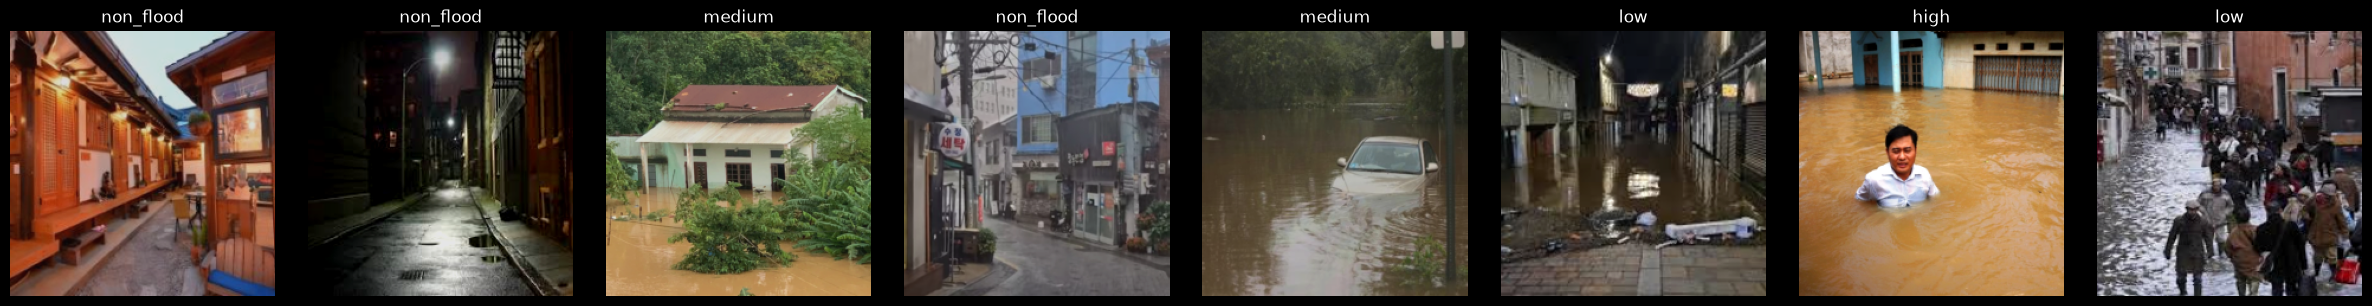

In [12]:
def show_batch(dataset, n=8):
    n = min(n, len(dataset))
    fig, axes = plt.subplots(1, n, figsize=(3*n, 3))
    if n == 1:
        axes = [axes]

    sample_indices = np.random.choice(len(dataset), n, replace=False)
    for ax, idx in zip(axes, sample_indices):
        img_tensor, label, path = dataset[idx]
        img = img_tensor.permute(1, 2, 0).numpy()
        img = img * np.array(IMAGENET_STD) + np.array(IMAGENET_MEAN)
        img = np.clip(img, 0, 1)
        ax.imshow(img)
        ax.set_title(CLASS_ORDER[label])
        ax.axis("off")

    plt.tight_layout()
    plt.show()

show_batch(train_dataset, n=8)

## 7. Build model — MobileNetV3 Large only

In [13]:
def build_mobilenetv3_large(num_classes: int, dropout: float = 0.35, pretrained: bool = True):
    """Build MobileNetV3-Large pretrained ImageNet cho bài toán 4-class flood severity.

    Lưu ý:
    - Giữ toàn bộ backbone pretrained.
    - Chỉ thay lớp classifier cuối cùng để tránh lệch kiến trúc khi load checkpoint.
    - MobileNetV3 phù hợp khi cần model nhẹ, inference nhanh nhưng vẫn giữ chất lượng tốt cho image classification.
    """
    weights = models.MobileNet_V3_Large_Weights.DEFAULT if pretrained else None
    model = models.mobilenet_v3_large(weights=weights)

    in_features = model.classifier[-1].in_features
    model.classifier[-1] = nn.Sequential(
        nn.Dropout(p=dropout),
        nn.Linear(in_features, num_classes),
    )

    return model


def count_trainable_params(model):
    total = sum(p.numel() for p in model.parameters())
    trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
    return total, trainable


model = build_mobilenetv3_large(
    num_classes=len(CLASS_ORDER),
    dropout=DROPOUT,
    pretrained=PRETRAINED,
).to(device)

total_params, trainable_params = count_trainable_params(model)
print(model)
print(f"Total params: {total_params:,}")
print(f"Trainable params: {trainable_params:,}")


Downloading: "https://download.pytorch.org/models/mobilenet_v3_large-5c1a4163.pth" to C:\Users\ASUS/.cache\torch\hub\checkpoints\mobilenet_v3_large-5c1a4163.pth


100%|██████████| 21.1M/21.1M [00:01<00:00, 18.1MB/s]


MobileNetV3(
  (features): Sequential(
    (0): Conv2dNormActivation(
      (0): Conv2d(3, 16, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
      (1): BatchNorm2d(16, eps=0.001, momentum=0.01, affine=True, bias=True, track_running_stats=True)
      (2): Hardswish()
    )
    (1): InvertedResidual(
      (block): Sequential(
        (0): Conv2dNormActivation(
          (0): Conv2d(16, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), groups=16, bias=False)
          (1): BatchNorm2d(16, eps=0.001, momentum=0.01, affine=True, bias=True, track_running_stats=True)
          (2): ReLU(inplace=True)
        )
        (1): Conv2dNormActivation(
          (0): Conv2d(16, 16, kernel_size=(1, 1), stride=(1, 1), bias=False)
          (1): BatchNorm2d(16, eps=0.001, momentum=0.01, affine=True, bias=True, track_running_stats=True)
        )
      )
    )
    (2): InvertedResidual(
      (block): Sequential(
        (0): Conv2dNormActivation(
          (0): Conv2d(16, 64, kern

## 8. Loss, optimizer, scheduler

In [14]:
def compute_class_weights_from_counts(train_counter, class_order):
    counts = np.array([train_counter[i] for i in range(len(class_order))], dtype=np.float32)
    if np.any(counts <= 0):
        raise ValueError("Có class không có ảnh trong train split.")

    # sqrt inverse frequency: nhẹ hơn inverse frequency thô.
    inv = (counts.sum() / (len(class_order) * counts)) ** CLASS_WEIGHT_POWER

    multipliers = np.array(
        [EXTRA_CLASS_MULTIPLIER.get(class_order[i], 1.0) for i in range(len(class_order))],
        dtype=np.float32,
    )
    weights = inv * multipliers

    # Normalize quanh mean=1 để loss ổn định hơn.
    weights = weights / weights.mean()
    weights = np.clip(weights, MIN_CLASS_WEIGHT, MAX_CLASS_WEIGHT)
    return weights


if USE_CLASS_WEIGHT_LOSS:
    class_weights = compute_class_weights_from_counts(train_counter, CLASS_ORDER)
    class_weights_tensor = torch.tensor(class_weights, dtype=torch.float32).to(device)
    print("Class weights:", {CLASS_ORDER[i]: float(class_weights[i]) for i in range(len(CLASS_ORDER))})
else:
    class_weights = None
    class_weights_tensor = None

criterion = nn.CrossEntropyLoss(
    weight=class_weights_tensor,
    label_smoothing=LABEL_SMOOTHING,
)


def build_optimizer(model):
    # Differential LR: backbone học chậm, classifier head học nhanh.
    backbone_params = []
    head_params = []

    for name, param in model.named_parameters():
        if not param.requires_grad:
            continue
        if name.startswith("classifier."):
            head_params.append(param)
        else:
            backbone_params.append(param)

    optimizer = optim.AdamW(
        [
            {"params": backbone_params, "lr": BACKBONE_LR},
            {"params": head_params, "lr": HEAD_LR},
        ],
        weight_decay=WEIGHT_DECAY,
    )
    return optimizer


optimizer = build_optimizer(model)

# ReduceLROnPlateau theo validation metric. mode='max' vì macro_f1/balanced_acc càng cao càng tốt.
scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode="max",
    factor=0.5,
    patience=3,
    min_lr=1e-7,
)

# AMP mới cho PyTorch 2.x.
amp_enabled = bool(USE_AMP and device.type == "cuda")
scaler = torch.amp.GradScaler(device.type, enabled=amp_enabled)

print("AMP enabled:", amp_enabled)
print("Optimizer param group LRs:", [group["lr"] for group in optimizer.param_groups])

Class weights: {'low': 0.9725231528282166, 'medium': 1.0103785991668701, 'high': 1.1832568645477295, 'non_flood': 0.8338415622711182}
AMP enabled: True
Optimizer param group LRs: [1e-05, 0.0002]


## 9. Train / evaluate functions

In [15]:
def compute_metrics(y_true, y_pred):
    return {
        "acc": accuracy_score(y_true, y_pred),
        "macro_f1": f1_score(y_true, y_pred, average="macro", zero_division=0),
        "balanced_acc": balanced_accuracy_score(y_true, y_pred),
    }


def compute_per_class_metrics(y_true, y_pred, class_order):
    precision, recall, f1, support = precision_recall_fscore_support(
        y_true,
        y_pred,
        labels=list(range(len(class_order))),
        zero_division=0,
    )
    result = {}
    for i, cls in enumerate(class_order):
        result[f"{cls}_precision"] = float(precision[i])
        result[f"{cls}_recall"] = float(recall[i])
        result[f"{cls}_f1"] = float(f1[i])
        result[f"{cls}_support"] = int(support[i])
    return result


def train_one_epoch(model, loader, optimizer, criterion, device, scaler=None):
    model.train()
    total_loss = 0.0
    y_true, y_pred = [], []

    pbar = tqdm(loader, desc="Train", leave=False)
    for images, labels, paths in pbar:
        images = images.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True)

        optimizer.zero_grad(set_to_none=True)

        with torch.amp.autocast(device_type=device.type, enabled=amp_enabled):
            logits = model(images)
            loss = criterion(logits, labels)

        if scaler is not None and amp_enabled:
            scaler.scale(loss).backward()
            scaler.unscale_(optimizer)
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=3.0)
            scaler.step(optimizer)
            scaler.update()
        else:
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=3.0)
            optimizer.step()

        total_loss += float(loss.item()) * images.size(0)
        preds = logits.argmax(dim=1)

        y_true.extend(labels.detach().cpu().numpy().tolist())
        y_pred.extend(preds.detach().cpu().numpy().tolist())

        pbar.set_postfix(loss=float(loss.item()))

    metrics = compute_metrics(y_true, y_pred)
    metrics.update(compute_per_class_metrics(y_true, y_pred, CLASS_ORDER))
    metrics["loss"] = total_loss / len(loader.dataset)
    return metrics


@torch.no_grad()
def evaluate(model, loader, criterion, device):
    model.eval()
    total_loss = 0.0
    y_true, y_pred, y_prob, img_paths = [], [], [], []

    for images, labels, paths in tqdm(loader, desc="Eval", leave=False):
        images = images.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True)

        with torch.amp.autocast(device_type=device.type, enabled=amp_enabled):
            logits = model(images)
            loss = criterion(logits, labels)

        probs = torch.softmax(logits, dim=1)
        preds = logits.argmax(dim=1)

        total_loss += float(loss.item()) * images.size(0)
        y_true.extend(labels.detach().cpu().numpy().tolist())
        y_pred.extend(preds.detach().cpu().numpy().tolist())
        y_prob.extend(probs.detach().cpu().numpy().tolist())
        img_paths.extend(list(paths))

    metrics = compute_metrics(y_true, y_pred)
    metrics.update(compute_per_class_metrics(y_true, y_pred, CLASS_ORDER))
    metrics["loss"] = total_loss / len(loader.dataset)

    return metrics, np.array(y_true), np.array(y_pred), np.array(y_prob), img_paths

## 10. Training loop

In [16]:
history = []
best_score = -1.0
best_epoch = -1
epochs_no_improve = 0

logger.info(
    "Training started | epochs=%d | batch_size=%d | device=%s | best_metric=%s",
    NUM_EPOCHS,
    BATCH_SIZE,
    device,
    BEST_METRIC,
)

for epoch in range(1, NUM_EPOCHS + 1):
    epoch_started = datetime.now()
    logger.info("Epoch %d/%d started", epoch, NUM_EPOCHS)

    try:
        train_metrics = train_one_epoch(
            model,
            train_loader,
            optimizer,
            criterion,
            device,
            scaler=scaler,
        )
        val_metrics, val_true, val_pred, val_prob, val_paths = evaluate(
            model,
            val_loader,
            criterion,
            device,
        )

        current_score = val_metrics[BEST_METRIC]
        scheduler.step(current_score)

        row = {
            "epoch": epoch,
            **{f"train_{k}": v for k, v in train_metrics.items()},
            **{f"val_{k}": v for k, v in val_metrics.items()},
            "lr_backbone": optimizer.param_groups[0]["lr"],
            "lr_head": optimizer.param_groups[1]["lr"],
        }
        history.append(row)

        logger.info(
            "Epoch %d/%d | train_loss=%.4f train_acc=%.4f train_macro_f1=%.4f | "
            "val_loss=%.4f val_acc=%.4f val_macro_f1=%.4f val_balanced_acc=%.4f",
            epoch,
            NUM_EPOCHS,
            train_metrics["loss"],
            train_metrics["acc"],
            train_metrics["macro_f1"],
            val_metrics["loss"],
            val_metrics["acc"],
            val_metrics["macro_f1"],
            val_metrics["balanced_acc"],
        )
        logger.info(
            "Epoch %d/%d | validation recall=%s | lr_backbone=%.2e lr_head=%.2e | elapsed=%s",
            epoch,
            NUM_EPOCHS,
            {cls: round(val_metrics[f"{cls}_recall"], 3) for cls in CLASS_ORDER},
            optimizer.param_groups[0]["lr"],
            optimizer.param_groups[1]["lr"],
            datetime.now() - epoch_started,
        )

        is_best = current_score > best_score + 1e-5

        checkpoint = {
            "epoch": epoch,
            "model_name": MODEL_NAME,
            "model_state_dict": model.state_dict(),
            "optimizer_state_dict": optimizer.state_dict(),
            "scheduler_state_dict": scheduler.state_dict(),
            "best_metric": BEST_METRIC,
            "best_score": float(max(best_score, current_score)),
            "current_score": float(current_score),
            "class_names": CLASS_ORDER,
            "class_order": CLASS_ORDER,
            "class_to_idx": CLASS_TO_IDX,
            "idx_to_class": IDX_TO_CLASS,
            "model_version": MODEL_VERSION,
            "image_size": IMAGE_SIZE,
            "preprocess": "letterbox",
            "letterbox_fill": LETTERBOX_FILL,
            "dropout": DROPOUT,
            "pretrained": PRETRAINED,
            "imagenet_mean": IMAGENET_MEAN,
            "imagenet_std": IMAGENET_STD,
            "config": CONFIG,
            "class_weights": None if class_weights is None else class_weights.tolist(),
            "split_csv_path": SPLIT_CSV_PATH,
            "history": history,
        }

        torch.save(checkpoint, LAST_CKPT_PATH)
        logger.info("Epoch %d/%d | saved last checkpoint: %s", epoch, NUM_EPOCHS, LAST_CKPT_PATH)

        if is_best:
            best_score = current_score
            best_epoch = epoch
            epochs_no_improve = 0
            checkpoint["best_score"] = float(best_score)
            torch.save(checkpoint, BEST_CKPT_PATH)
            logger.info(
                "Epoch %d/%d | new best %s=%.4f | saved: %s",
                epoch,
                NUM_EPOCHS,
                BEST_METRIC,
                best_score,
                BEST_CKPT_PATH,
            )
        else:
            epochs_no_improve += 1
            logger.info(
                "Epoch %d/%d | no improvement: %d/%d",
                epoch,
                NUM_EPOCHS,
                epochs_no_improve,
                PATIENCE,
            )

        history_df = pd.DataFrame(history)
        history_df.to_csv(HISTORY_CSV_PATH, index=False)
        logger.info("Epoch %d/%d | history updated: %s", epoch, NUM_EPOCHS, HISTORY_CSV_PATH)

        if epochs_no_improve >= PATIENCE:
            logger.info(
                "Early stopping at epoch %d | best_epoch=%d | best_%s=%.4f",
                epoch,
                best_epoch,
                BEST_METRIC,
                best_score,
            )
            break
    except Exception:
        logger.exception("Epoch %d/%d failed", epoch, NUM_EPOCHS)
        raise

logger.info(
    "Training finished | best_epoch=%d | best_%s=%.4f | best_checkpoint=%s | last_checkpoint=%s",
    best_epoch,
    BEST_METRIC,
    best_score,
    BEST_CKPT_PATH,
    LAST_CKPT_PATH,
)

2026-09-07 11:49:05 | INFO | Training started | epochs=35 | batch_size=32 | device=cuda | best_metric=macro_f1
2026-09-07 11:49:05 | INFO | Epoch 1/35 started


Train:   0%|          | 0/36 [00:00<?, ?it/s]

Eval:   0%|          | 0/8 [00:00<?, ?it/s]

2026-09-07 11:53:55 | INFO | Epoch 1/35 | train_loss=1.1920 train_acc=0.5198 train_macro_f1=0.4773 | val_loss=0.9840 val_acc=0.6557 val_macro_f1=0.6184 val_balanced_acc=0.6310
2026-09-07 11:53:55 | INFO | Epoch 1/35 | validation recall={'low': 0.276, 'medium': 0.778, 'high': 0.558, 'non_flood': 0.912} | lr_backbone=1.00e-05 lr_head=2.00e-04 | elapsed=0:04:50.711519
2026-09-07 11:53:56 | INFO | Epoch 1/35 | saved last checkpoint: ./models\mobilenetv3_large_relabel\flood_mobilenetv3_large_relabel_last.pth
2026-09-07 11:53:56 | INFO | Epoch 1/35 | new best macro_f1=0.6184 | saved: ./models\mobilenetv3_large_relabel\flood_mobilenetv3_large_relabel_best.pth
2026-09-07 11:53:56 | INFO | Epoch 1/35 | history updated: ./models\mobilenetv3_large_relabel\history_mobilenetv3_large.csv
2026-09-07 11:53:56 | INFO | Epoch 2/35 started


Train:   0%|          | 0/36 [00:00<?, ?it/s]

...

Eval:   0%|          | 0/8 [00:00<?, ?it/s]

2026-09-07 12:10:17 | INFO | Epoch 22/35 | train_loss=0.2871 train_acc=0.9868 train_macro_f1=0.9862 | val_loss=0.7852 val_acc=0.7623 val_macro_f1=0.7442 val_balanced_acc=0.7473
2026-09-07 12:10:17 | INFO | Epoch 22/35 | validation recall={'low': 0.707, 'medium': 0.556, 'high': 0.827, 'non_flood': 0.9} | lr_backbone=5.00e-06 lr_head=1.00e-04 | elapsed=0:00:38.936986
2026-09-07 12:10:17 | INFO | Epoch 22/35 | saved last checkpoint: ./models\mobilenetv3_large_relabel\flood_mobilenetv3_large_relabel_last.pth
2026-09-07 12:10:17 | INFO | Epoch 22/35 | no improvement: 6/7
2026-09-07 12:10:17 | INFO | Epoch 22/35 | history updated: ./models\mobilenetv3_large_relabel\history_mobilenetv3_large.csv
2026-09-07 12:10:17 | INFO | Epoch 23/35 started


Train:   0%|          | 0/36 [00:00<?, ?it/s]

Eval:   0%|          | 0/8 [00:00<?, ?it/s]

2026-09-07 12:10:56 | INFO | Epoch 23/35 | train_loss=0.2841 train_acc=0.9930 train_macro_f1=0.9929 | val_loss=0.7908 val_acc=0.7664 val_macro_f1=0.7501 val_balanced_acc=0.7540
2026-09-07 12:10:56 | INFO | Epoch 23/35 | validation recall={'low': 0.759, 'medium': 0.556, 'high': 0.827, 'non_flood': 0.875} | lr_backbone=5.00e-06 lr_head=1.00e-04 | elapsed=0:00:39.173257
2026-09-07 12:10:57 | INFO | Epoch 23/35 | saved last checkpoint: ./models\mobilenetv3_large_relabel\flood_mobilenetv3_large_relabel_last.pth
2026-09-07 12:10:57 | INFO | Epoch 23/35 | no improvement: 7/7
2026-09-07 12:10:57 | INFO | Epoch 23/35 | history updated: ./models\mobilenetv3_large_relabel\history_mobilenetv3_large.csv
2026-09-07 12:10:57 | INFO | Early stopping at epoch 23 | best_epoch=16 | best_macro_f1=0.7642
2026-09-07 12:10:57 | INFO | Training finished | best_epoch=16 | best_macro_f1=0.7642 | best_checkpoint=./models\mobilenetv3_large_relabel\flood_mobilenetv3_large_relabel_best.pth | last_checkpoint=./model

## 11. Plot training history

,epoch,train_acc,train_macro_f1,train_balanced_acc,train_low_precision,train_low_recall,train_low_f1,train_low_support,train_medium_precision,train_medium_recall,...,val_high_recall,val_high_f1,val_high_support,val_non_flood_precision,val_non_flood_recall,val_non_flood_f1,val_non_flood_support,val_loss,lr_backbone,lr_head
18,19,0.976253,0.975064,0.975403,0.967273,0.977941,0.972578,272,0.956349,0.956349,...,0.865385,0.756303,52,0.911392,0.900,0.905660,80,0.811614,0.000010,0.0002
19,20,0.982410,0.981669,0.981728,0.977695,0.966912,0.972274,272,0.980000,0.972222,...,0.846154,0.758621,52,0.909091,0.875,0.891720,80,0.803341,0.000005,0.0001
20,21,0.992084,0.991769,0.991813,0.981818,0.992647,0.987203,272,0.992000,0.984127,...,0.826923,0.767857,52,0.909091,0.875,0.891720,80,0.784191,0.000005,0.0001
21,22,0.986807,0.986195,0.986530,0.974638,0.988971,0.981752,272,0.984000,0.976190,...,0.826923,0.767857,52,0.867470,0.900,0.883436,80,0.785179,0.000005,0.0001
22,23,0.992964,0.992912,0.992951,0.988930,0.985294,0.987109,272,0.992095,0.996032,...,0.826923,0.774775,52,0.909091,0.875,0.891720,80,0.790832,0.000005,0.0001


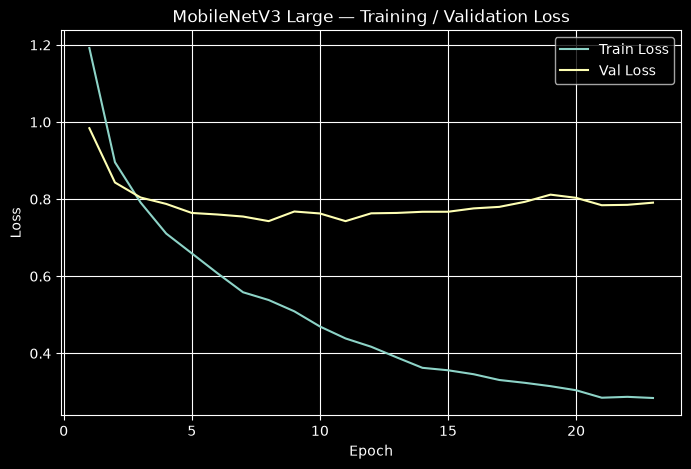

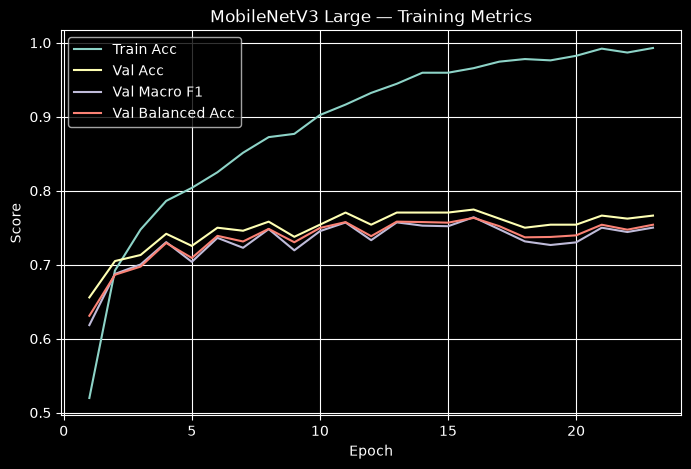

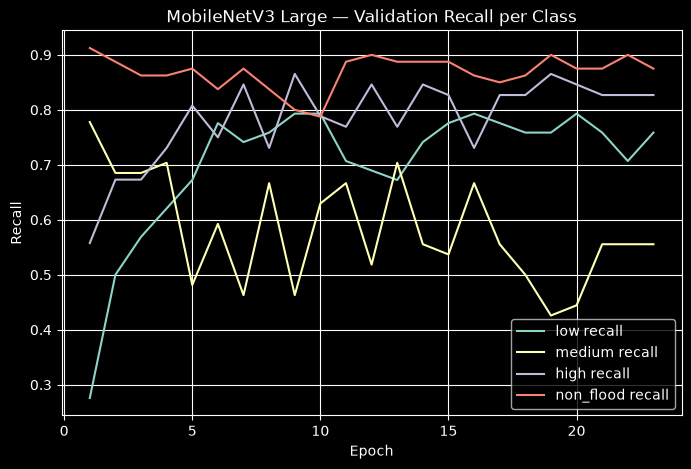

Saved figures:
./models\mobilenetv3_large_relabel\loss_curve_mobilenetv3_large.png
./models\mobilenetv3_large_relabel\metrics_curve_mobilenetv3_large.png
./models\mobilenetv3_large_relabel\val_recall_per_class_mobilenetv3_large.png


In [17]:
history_df = pd.DataFrame(history)
display(history_df.tail())

def plot_history(history_df):
    plt.figure(figsize=(8, 5))
    plt.plot(history_df["epoch"], history_df["train_loss"], label="Train Loss")
    plt.plot(history_df["epoch"], history_df["val_loss"], label="Val Loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.title("MobileNetV3 Large — Training / Validation Loss")
    plt.legend()
    plt.grid(True)
    loss_fig = os.path.join(OUTPUT_DIR, "loss_curve_mobilenetv3_large.png")
    plt.savefig(loss_fig, dpi=160, bbox_inches="tight")
    plt.show()

    plt.figure(figsize=(8, 5))
    plt.plot(history_df["epoch"], history_df["train_acc"], label="Train Acc")
    plt.plot(history_df["epoch"], history_df["val_acc"], label="Val Acc")
    plt.plot(history_df["epoch"], history_df["val_macro_f1"], label="Val Macro F1")
    plt.plot(history_df["epoch"], history_df["val_balanced_acc"], label="Val Balanced Acc")
    plt.xlabel("Epoch")
    plt.ylabel("Score")
    plt.title("MobileNetV3 Large — Training Metrics")
    plt.legend()
    plt.grid(True)
    metrics_fig = os.path.join(OUTPUT_DIR, "metrics_curve_mobilenetv3_large.png")
    plt.savefig(metrics_fig, dpi=160, bbox_inches="tight")
    plt.show()

    plt.figure(figsize=(8, 5))
    for cls in CLASS_ORDER:
        col = f"val_{cls}_recall"
        if col in history_df.columns:
            plt.plot(history_df["epoch"], history_df[col], label=f"{cls} recall")
    plt.xlabel("Epoch")
    plt.ylabel("Recall")
    plt.title("MobileNetV3 Large — Validation Recall per Class")
    plt.legend()
    plt.grid(True)
    recall_fig = os.path.join(OUTPUT_DIR, "val_recall_per_class_mobilenetv3_large.png")
    plt.savefig(recall_fig, dpi=160, bbox_inches="tight")
    plt.show()

    print("Saved figures:")
    print(loss_fig)
    print(metrics_fig)
    print(recall_fig)

plot_history(history_df)

## 12. Load best checkpoint và test evaluation

In [18]:
# Báo cáo cuối chỉ dùng test split độc lập; train/val tuyệt đối không được trộn vào.
train_groups_set = set(train_df["perceptual_group"])
val_groups_set = set(val_df["perceptual_group"])
test_groups_set = set(test_df["perceptual_group"])
assert train_groups_set.isdisjoint(val_groups_set)
assert train_groups_set.isdisjoint(test_groups_set)
assert val_groups_set.isdisjoint(test_groups_set)
print(f"Final evaluation split: test only ({len(test_df)} images)")

ckpt = torch.load(BEST_CKPT_PATH, map_location=device, weights_only=False)
print("Loaded checkpoint:", BEST_CKPT_PATH)
print("Checkpoint class_names:", ckpt["class_names"])
print("Checkpoint class_to_idx:", ckpt["class_to_idx"])
print("Best epoch:", ckpt["epoch"], "Best score:", ckpt["best_score"])

# Kiểm tra mapping để tránh lỗi lệch label.
assert ckpt["class_names"] == CLASS_ORDER, "Checkpoint class_names không khớp CLASS_ORDER hiện tại."

model = build_mobilenetv3_large(
    num_classes=len(ckpt["class_names"]),
    dropout=ckpt.get("dropout", DROPOUT),
    pretrained=False,
).to(device)
model.load_state_dict(ckpt["model_state_dict"])

# Criterion cho test dùng lại weight/label_smoothing để loss nhất quán.
test_metrics, test_true, test_pred, test_prob, test_paths = evaluate(model, test_loader, criterion, device)

print("\nTEST METRICS")
for k in ["loss", "acc", "macro_f1", "balanced_acc"]:
    print(f"{k}: {test_metrics[k]:.4f}")

print("\nTEST RECALL")
for cls in CLASS_ORDER:
    print(f"{cls}: {test_metrics[f'{cls}_recall']:.4f}")

report_text = classification_report(
    test_true,
    test_pred,
    target_names=CLASS_ORDER,
    digits=4,
    zero_division=0,
)
print("\nClassification report:")
print(report_text)

report_txt_path = os.path.join(OUTPUT_DIR, "classification_report_test_mobilenetv3_large_v2.txt")
with open(report_txt_path, "w", encoding="utf-8") as f:
    f.write(report_text)

report_dict = classification_report(
    test_true,
    test_pred,
    target_names=CLASS_ORDER,
    digits=4,
    zero_division=0,
    output_dict=True,
)
report_csv_path = os.path.join(OUTPUT_DIR, "classification_report_test_mobilenetv3_large_v2.csv")
pd.DataFrame(report_dict).transpose().to_csv(report_csv_path)

test_metrics_path = os.path.join(OUTPUT_DIR, "test_metrics_mobilenetv3_large_v2.json")
with open(test_metrics_path, "w", encoding="utf-8") as f:
    metrics_payload = {k: float(v) if isinstance(v, (np.floating, float)) else int(v) if isinstance(v, (np.integer, int)) else v
                       for k, v in test_metrics.items()}
    metrics_payload.update({"evaluation_split": "test", "num_samples": len(test_df), "model_version": MODEL_VERSION})
    json.dump(metrics_payload, f, ensure_ascii=False, indent=2)

print("Saved:", report_txt_path)
print("Saved:", report_csv_path)
print("Saved:", test_metrics_path)

Loaded checkpoint: ./models\mobilenetv3_large_relabel\flood_mobilenetv3_large_relabel_best.pth
Checkpoint class_names: ['low', 'medium', 'high', 'non_flood']
Checkpoint class_to_idx: {'low': 0, 'medium': 1, 'high': 2, 'non_flood': 3}
Best epoch: 16 Best score: 0.7641690118531533


Eval:   0%|          | 0/8 [00:00<?, ?it/s]


TEST METRICS
loss: 0.8004
acc: 0.7377
macro_f1: 0.7221
balanced_acc: 0.7204

TEST RECALL
low: 0.8103
medium: 0.5741
high: 0.6346
non_flood: 0.8625

Classification report:
              precision    recall  f1-score   support

         low     0.5949    0.8103    0.6861        58
      medium     0.6078    0.5741    0.5905        54
        high     0.8049    0.6346    0.7097        52
   non_flood     0.9452    0.8625    0.9020        80

    accuracy                         0.7377       244
   macro avg     0.7382    0.7204    0.7221       244
weighted avg     0.7574    0.7377    0.7407       244

Saved: ./models\mobilenetv3_large_relabel\classification_report_test_mobilenetv3_large.txt
Saved: ./models\mobilenetv3_large_relabel\classification_report_test_mobilenetv3_large.csv
Saved: ./models\mobilenetv3_large_relabel\test_metrics_mobilenetv3_large.json


## 13. Confusion matrix

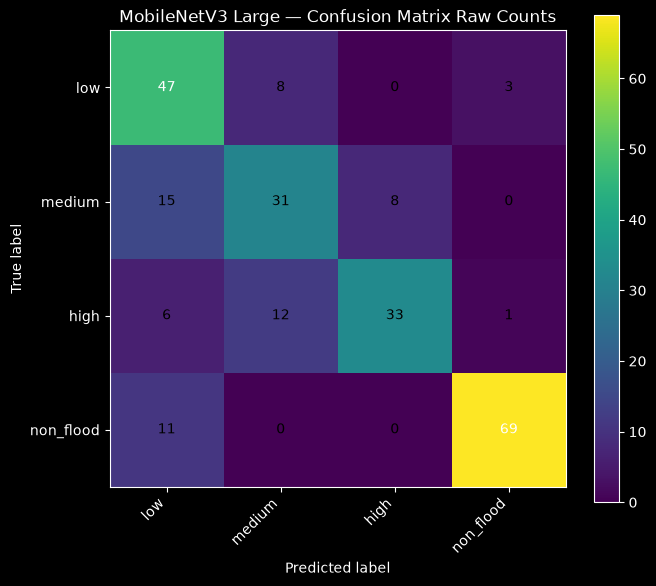

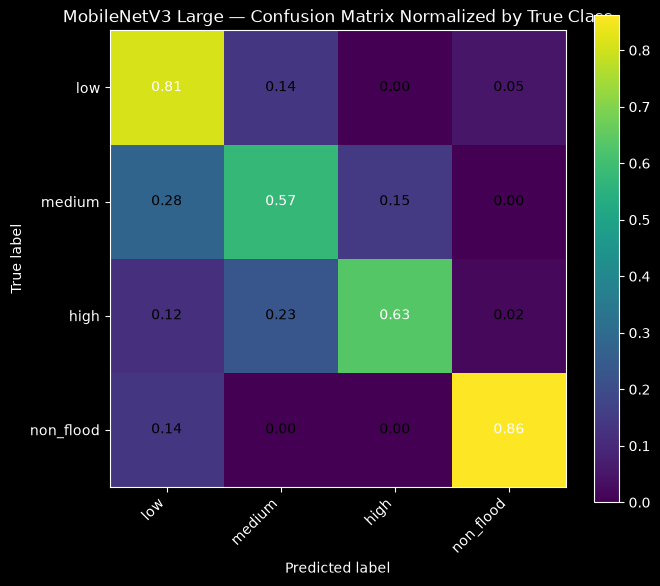

Saved: ./models\mobilenetv3_large_relabel\cm_raw_test_mobilenetv3_large.png
Saved: ./models\mobilenetv3_large_relabel\cm_norm_test_mobilenetv3_large.png
Saved: ./models\mobilenetv3_large_relabel\cm_raw_test_mobilenetv3_large.csv
Saved: ./models\mobilenetv3_large_relabel\cm_norm_test_mobilenetv3_large.csv


In [19]:
def plot_confusion_matrix(cm, class_names, title, normalize=False, save_path=None):
    plt.figure(figsize=(7, 6))
    plt.imshow(cm, interpolation="nearest")
    plt.title(title)
    plt.colorbar()

    tick_marks = np.arange(len(class_names))
    plt.xticks(tick_marks, class_names, rotation=45, ha="right")
    plt.yticks(tick_marks, class_names)

    fmt = ".2f" if normalize else "d"
    thresh = cm.max() / 2.0 if cm.size > 0 else 0

    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            value = cm[i, j]
            plt.text(
                j,
                i,
                format(value, fmt),
                ha="center",
                va="center",
                color="white" if value > thresh else "black",
            )

    plt.ylabel("True label")
    plt.xlabel("Predicted label")
    plt.tight_layout()

    if save_path:
        plt.savefig(save_path, dpi=160, bbox_inches="tight")
    plt.show()


cm_raw = confusion_matrix(test_true, test_pred, labels=list(range(len(CLASS_ORDER))))
cm_norm = confusion_matrix(test_true, test_pred, labels=list(range(len(CLASS_ORDER))), normalize="true")

cm_raw_path = os.path.join(OUTPUT_DIR, "cm_raw_test_mobilenetv3_large.png")
cm_norm_path = os.path.join(OUTPUT_DIR, "cm_norm_test_mobilenetv3_large.png")
cm_raw_csv = os.path.join(OUTPUT_DIR, "cm_raw_test_mobilenetv3_large.csv")
cm_norm_csv = os.path.join(OUTPUT_DIR, "cm_norm_test_mobilenetv3_large.csv")

pd.DataFrame(cm_raw, index=CLASS_ORDER, columns=CLASS_ORDER).to_csv(cm_raw_csv)
pd.DataFrame(cm_norm, index=CLASS_ORDER, columns=CLASS_ORDER).to_csv(cm_norm_csv)

plot_confusion_matrix(
    cm_raw,
    CLASS_ORDER,
    "MobileNetV3 Large — Confusion Matrix Raw Counts",
    normalize=False,
    save_path=cm_raw_path,
)

plot_confusion_matrix(
    cm_norm,
    CLASS_ORDER,
    "MobileNetV3 Large — Confusion Matrix Normalized by True Class",
    normalize=True,
    save_path=cm_norm_path,
)

print("Saved:", cm_raw_path)
print("Saved:", cm_norm_path)
print("Saved:", cm_raw_csv)
print("Saved:", cm_norm_csv)

## 14. Xuất danh sách ảnh đoán sai để tiếp tục clean/relabel

In [20]:
mis_rows = []

for path, t, p, probs in zip(test_paths, test_true, test_pred, test_prob):
    if int(t) != int(p):
        row = {
            "path": path,
            "true_idx": int(t),
            "pred_idx": int(p),
            "true_label": CLASS_ORDER[int(t)],
            "pred_label": CLASS_ORDER[int(p)],
            "confidence": float(np.max(probs)),
            "true_prob": float(probs[int(t)]),
            "pred_prob": float(probs[int(p)]),
            "error_pair": f"{CLASS_ORDER[int(t)]}_to_{CLASS_ORDER[int(p)]}",
            "file_name": os.path.basename(path),
        }

        for i, cls in enumerate(CLASS_ORDER):
            row[f"prob_{cls}"] = float(probs[i])

        mis_rows.append(row)

mis_df = pd.DataFrame(mis_rows)
mis_path = os.path.join(OUTPUT_DIR, "misclassified_test_mobilenetv3_large.csv")
mis_df.to_csv(mis_path, index=False)

print("Misclassified count:", len(mis_df))
print("Saved:", mis_path)

if len(mis_df) > 0:
    display(mis_df.sort_values(["error_pair", "confidence"], ascending=[True, False]).head(30))

# Tổng hợp lỗi theo cặp, đặc biệt quan tâm low/non_flood và medium/high.
if len(mis_df) > 0:
    pair_summary = (
        mis_df.groupby(["true_label", "pred_label"])
        .size()
        .reset_index(name="count")
        .sort_values("count", ascending=False)
    )
    pair_summary_path = os.path.join(OUTPUT_DIR, "misclassified_pair_summary_mobilenetv3_large.csv")
    pair_summary.to_csv(pair_summary_path, index=False)
    display(pair_summary)
    print("Saved:", pair_summary_path)

Misclassified count: 64
Saved: ./models\mobilenetv3_large_relabel\misclassified_test_mobilenetv3_large.csv


,path,true_idx,pred_idx,true_label,pred_label,confidence,true_prob,pred_prob,error_pair,file_name,prob_low,prob_medium,prob_high,prob_non_flood
40,e:\RHNA\1Visual\NCKH\model\Dataset_Flood\high\...,2,0,high,low,0.972168,0.009262,0.972168,high_to_low,images (42).jpg,0.972168,0.018433,0.009262,0.000032
43,e:\RHNA\1Visual\NCKH\model\Dataset_Flood\high\...,2,0,high,low,0.967285,0.021469,0.967285,high_to_low,images - 2025-01-28T155325.390.jpg,0.967285,0.010239,0.021469,0.000782
50,e:\RHNA\1Visual\NCKH\model\Dataset_Flood\high\...,2,0,high,low,0.710938,0.105225,0.710938,high_to_low,OIP (26).webp,0.710938,0.156982,0.105225,0.026779
51,e:\RHNA\1Visual\NCKH\model\Dataset_Flood\high\...,2,0,high,low,0.603516,0.223511,0.603516,high_to_low,OIP (33).webp,0.603516,0.173096,0.223511,0.000040
39,e:\RHNA\1Visual\NCKH\model\Dataset_Flood\high\...,2,0,high,low,0.530273,0.113953,0.530273,high_to_low,images (22).jpg,0.530273,0.355225,0.113953,0.000441
42,e:\RHNA\1Visual\NCKH\model\Dataset_Flood\high\...,2,0,high,low,0.470215,0.074646,0.470215,high_to_low,images - 2025-01-28T154241.750.jpg,0.470215,0.041779,0.074646,0.413330
36,e:\RHNA\1Visual\NCKH\model\Dataset_Flood\high\...,2,1,high,medium,0.960938,0.006901,0.960938,high_to_medium,flood_4762.jpg,0.032104,0.960938,0.006901,0.000119
37,e:\RHNA\1Visual\NCKH\model\Dataset_Flood\high\...,2,1,high,medium,0.884277,0.071350,0.884277,high_to_medium,flood_6158.jpg,0.044556,0.884277,0.071350,0.000041
41,e:\RHNA\1Visual\NCKH\model\Dataset_Flood\high\...,2,1,high,medium,0.842285,0.139648,0.842285,high_to_medium,images (7).jpg,0.015854,0.842285,0.139648,0.002310
49,e:\RHNA\1Visual\NCKH\model\Dataset_Flood\high\...,2,1,high,medium,0.808105,0.169067,0.808105,high_to_medium,lu_lut.webp,0.004143,0.808105,0.169067,0.018799


,true_label,pred_label,count
6,medium,low,15
1,high,medium,12
7,non_flood,low,11
3,low,medium,8
5,medium,high,8
0,high,low,6
4,low,non_flood,3
2,high,non_flood,1


Saved: ./models\mobilenetv3_large_relabel\misclassified_pair_summary_mobilenetv3_large.csv


In [21]:
def copy_misclassified_by_pair(mis_df, output_dir, max_per_pair=None):
    if len(mis_df) == 0:
        print("No misclassified images to copy.")
        return None

    review_dir = os.path.join(output_dir, "review_misclassified_by_pair_mobilenetv3_large")
    if os.path.exists(review_dir):
        shutil.rmtree(review_dir)
    os.makedirs(review_dir, exist_ok=True)

    copied = 0
    for pair, group in mis_df.groupby("error_pair"):
        pair_dir = os.path.join(review_dir, pair)
        os.makedirs(pair_dir, exist_ok=True)

        group = group.sort_values("confidence", ascending=False)
        if max_per_pair is not None:
            group = group.head(max_per_pair)

        for _, row in group.iterrows():
            src = row["path"]
            stem = Path(src).stem
            suffix = Path(src).suffix
            dst_name = f"T-{row['true_label']}_P-{row['pred_label']}_conf-{row['confidence']:.2f}_{stem}{suffix}"
            dst = os.path.join(pair_dir, dst_name)
            try:
                shutil.copy2(src, dst)
                copied += 1
            except Exception as e:
                print("Copy failed:", src, repr(e))

    print(f"Copied {copied} misclassified images to:", review_dir)
    return review_dir


review_dir = copy_misclassified_by_pair(mis_df, OUTPUT_DIR, max_per_pair=None)

Copied 64 misclassified images to: ./models\mobilenetv3_large_relabel\review_misclassified_by_pair_mobilenetv3_large


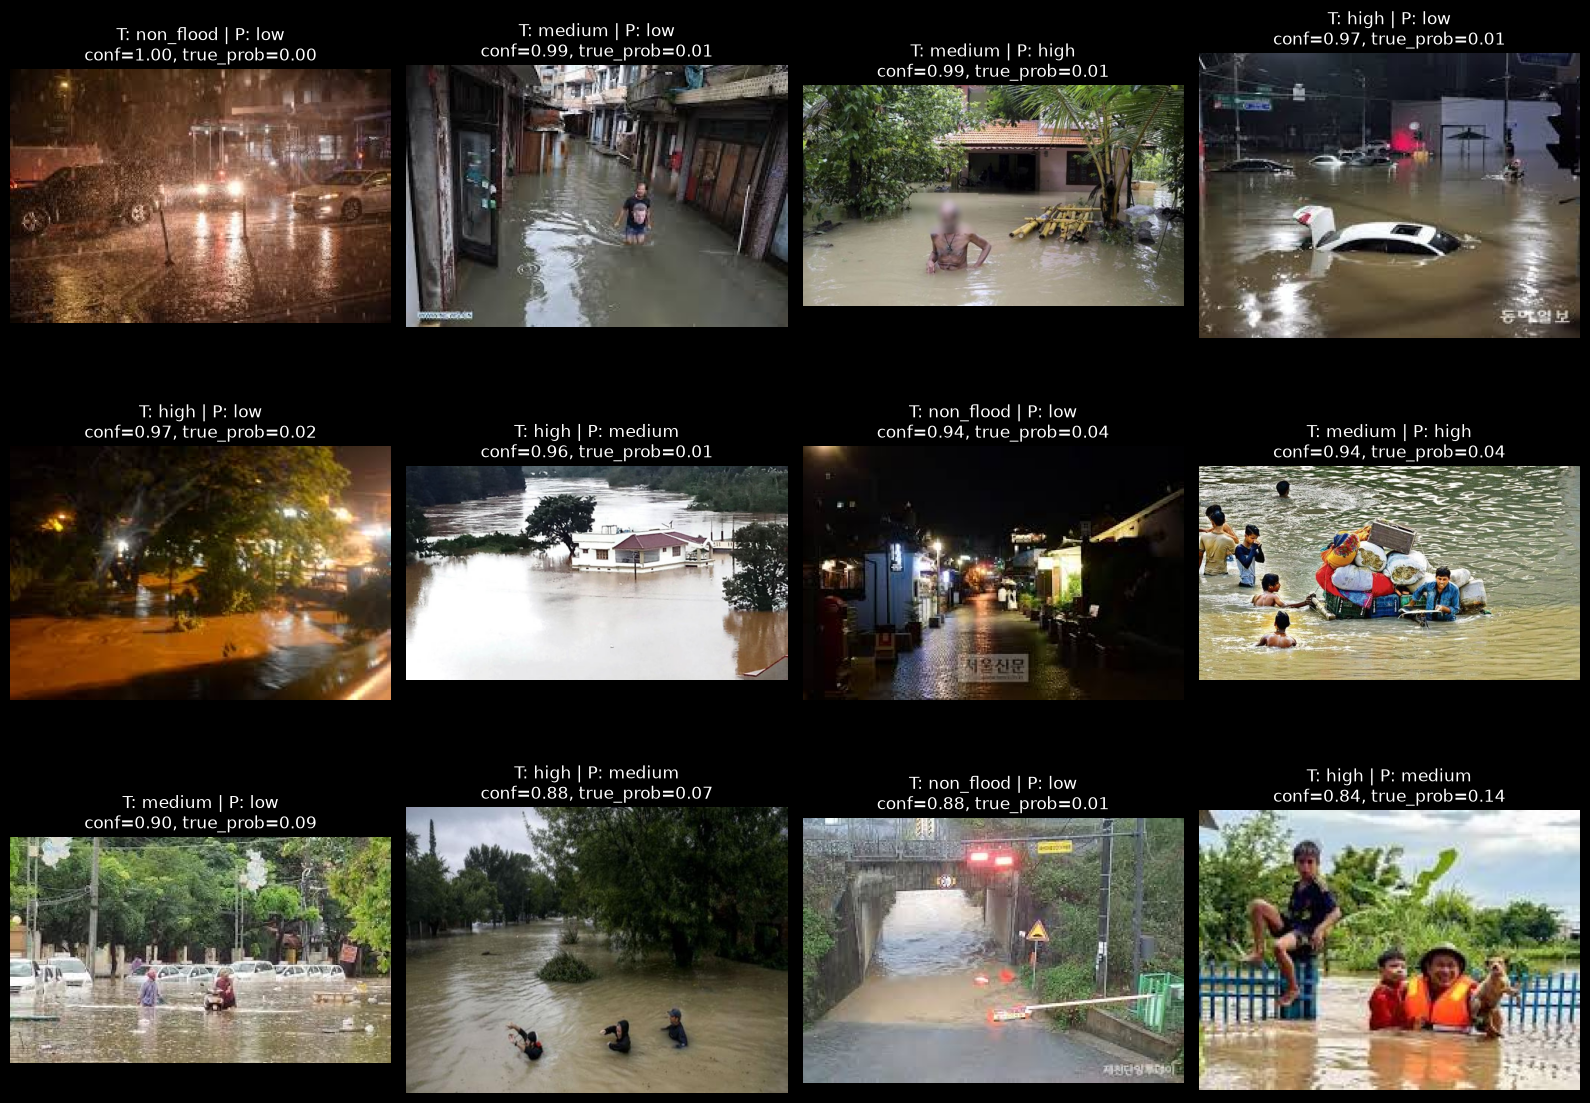

Saved: ./models\mobilenetv3_large_relabel\misclassified_examples_mobilenetv3_large.png


In [22]:
def show_misclassified(mis_df, n=12, sort_by="confidence"):
    if len(mis_df) == 0:
        print("No misclassified images.")
        return

    if sort_by and sort_by in mis_df.columns:
        sample = mis_df.sort_values(sort_by, ascending=False).head(min(n, len(mis_df)))
    else:
        sample = mis_df.sample(min(n, len(mis_df)), random_state=SEED)

    cols = 4
    rows = int(np.ceil(len(sample) / cols))
    fig, axes = plt.subplots(rows, cols, figsize=(4 * cols, 4 * rows))
    axes = np.array(axes).reshape(-1)

    for ax, (_, row) in zip(axes, sample.iterrows()):
        img = Image.open(row["path"]).convert("RGB")
        ax.imshow(img)
        ax.set_title(
            f"T: {row['true_label']} | P: {row['pred_label']}\n"
            f"conf={row['confidence']:.2f}, true_prob={row['true_prob']:.2f}"
        )
        ax.axis("off")

    for ax in axes[len(sample):]:
        ax.axis("off")

    plt.tight_layout()
    fig_path = os.path.join(OUTPUT_DIR, "misclassified_examples_mobilenetv3_large.png")
    plt.savefig(fig_path, dpi=160, bbox_inches="tight")
    plt.show()
    print("Saved:", fig_path)


show_misclassified(mis_df, n=12, sort_by="confidence")

## 15. Inference test cho 1 ảnh

In [23]:
@torch.no_grad()
def predict_image(image_path, checkpoint_path=BEST_CKPT_PATH, top_k=4):
    ckpt = torch.load(checkpoint_path, map_location=device, weights_only=False)
    class_names = ckpt["class_names"]
    image_size = ckpt.get("image_size", IMAGE_SIZE)
    letterbox_fill = ckpt.get("letterbox_fill", LETTERBOX_FILL)
    mean = ckpt.get("imagenet_mean", IMAGENET_MEAN)
    std = ckpt.get("imagenet_std", IMAGENET_STD)

    model = build_mobilenetv3_large(
        num_classes=len(class_names),
        dropout=ckpt.get("dropout", DROPOUT),
        pretrained=False,
    ).to(device)
    model.load_state_dict(ckpt["model_state_dict"])
    model.eval()

    transform = transforms.Compose([
        Letterbox(image_size, letterbox_fill),
        transforms.ToTensor(),
        transforms.Normalize(mean=mean, std=std),
    ])

    with Image.open(image_path) as img:
        img = img.convert("RGB")
        x = transform(img).unsqueeze(0).to(device)

    logits = model(x)
    probs = torch.softmax(logits, dim=1)[0].detach().cpu().numpy()

    order = np.argsort(probs)[::-1][:top_k]
    result = [(class_names[i], float(probs[i])) for i in order]

    pred_label = result[0][0]
    confidence = result[0][1]

    return {
        "image_path": image_path,
        "pred_label": pred_label,
        "confidence": confidence,
        "top_k": result,
    }


# Ví dụ:
# sample_path = test_df.iloc[0]["path"]
# predict_image(sample_path)

## Ghi chú dùng sau khi train MobileNetV3 Large

Sau mỗi lần train, mở các file này trong `OUTPUT_DIR/mobilenetv3_large_relabel_v2`:

- `split_train_val_test_mobilenetv3_large_v2.csv`: grouped split cố định; một perceptual group không thể nằm ở nhiều split.
- `perceptual_near_duplicates_mobilenetv3_large_v2.csv`: audit ảnh gần giống cùng group.
- `perceptual_conflicts_cross_label_mobilenetv3_large_v2.csv`: ảnh gần giống nhưng khác nhãn đã bị loại để review.
- `history_mobilenetv3_large.csv`: log từng epoch.
- `classification_report_test_mobilenetv3_large.txt`: xem `macro_f1`, `balanced_acc`, recall từng class.
- `cm_raw_test_mobilenetv3_large.png` và `cm_norm_test_mobilenetv3_large.png`: xem class nào còn nhầm nhiều.
- `misclassified_test_mobilenetv3_large.csv`: danh sách ảnh đoán sai kèm confidence/probability.
- `review_misclassified_by_pair_mobilenetv3_large/`: ảnh đoán sai đã copy theo từng cặp lỗi, dùng để relabel tiếp.

Ưu tiên kiểm tra các cặp lỗi:

1. `low ↔ non_flood`: thường do ảnh chỉ mưa/đường ướt/vũng nhỏ nhưng bị gán low.
2. `low ↔ medium`: thường do thiếu mốc đầu gối/bánh xe/yên xe.
3. `medium ↔ high`: thường do model học cảm giác thảm họa thay vì độ sâu nước.

Mốc đánh giá nên hướng tới trước khi xem là ổn:

- `non_flood recall >= 0.90`
- `low recall >= 0.80`
- `medium recall >= 0.75`
- `high recall >= 0.75`
- `macro_f1 >= 0.80`
- `balanced_acc >= 0.80`

Nếu `train_acc` rất cao nhưng `val_macro_f1` thấp, đừng tăng epoch. Hãy:
- clean lại nhãn ambiguous,
- bổ sung ảnh `high` có mốc rõ,
- bổ sung hard negative `non_flood` như mưa, đường ướt, vũng nước nhỏ,
- tránh augmentation/crop quá mạnh làm mất vật tham chiếu.